# World Happiness Report!😊

![](https://media.giphy.com/media/11sBLVxNs7v6WA/giphy.gif)

# **HISTORY**[](https://en.wikipedia.org/wiki/World_Happiness_Report)

In July 2011, the UN General Assembly adopted resolution 65/309 Happiness: Towards a Holistic Definition of Development inviting member countries to measure the happiness of their people and to use the data to help guide public policy. On April 2, 2012, this was followed by the first UN High Level Meeting called Wellbeing and Happiness: Defining a New Economic Paradigm, which was chaired by UN Secretary General Ban Ki-moon and Prime Minister Jigme Thinley of Bhutan, a nation that adopted gross national happiness instead of gross domestic product as their main development indicator.

The first World Happiness Report was released on April 1, 2012 as a foundational text for the UN High Level Meeting: Well-being and Happiness: Defining a New Economic Paradigm, drawing international attention. The report outlined the state of world happiness, causes of happiness and misery, and policy implications highlighted by case studies. In 2013, the second World Happiness Report was issued, and since then has been issued on an annual basis with the exception of 2014. The report primarily uses data from the Gallup World Poll. Each annual report is available to the public to download on the World Happiness Report website

# **METHODS AND PHILOSOPHY**

**The rankings of national happiness are based on a Cantril ladder survey. Nationally representative samples of respondents are asked to think of a ladder, with the best possible life for them being a 10, and the worst possible life being a 0. They are then asked to rate their own current lives on that 0 to 10 scale. The report correlates the results with various life factors.
In the reports, experts in fields including economics, psychology, survey analysis, and national statistics, describe how measurements of well-being can be used effectively to assess the progress of nations, and other topics. Each report is organized by chapters that delve deeper into issues relating to happiness, including mental illness, the objective benefits of happiness, the importance of ethics, policy implications, and links with the Organisation for Economic Co-operation and Development's (OECD) approach to measuring subjective well-being and other international and national efforts.**

# **MEANING OF TERMS USED IN THE DATASET**

* **GDP per capita**:GDP per capita is a measure of a country's economic output that accounts for its number of people.	
* **Social support**:Social support means having friends and other people, including family, to turn to in times of need or crisis to give you a broader focus and positive self-image. Social support enhances quality of life and provides a buffer against adverse life events.
* **Healthy life expectancy**:Healthy Life Expectancy is the average number of years that a newborn can expect to live in "full health"—in other words, not hampered by disabling illnesses or injuries.
* **Freedom to make life choices**:Freedom of choice describes an individual's opportunity and autonomy to perform an action selected from at least two available options, unconstrained by external parties.
* **Generosity**:the quality of being kind and generous.
* **Perceptions of corruption**:The Corruption Perceptions Index (CPI) is an index published annually by Transparency International since 1995 which ranks countries "by their perceived levels of public sector corruption, as determined by expert assessments and opinion surveys.

[src](http://google.com)

**Importing Important Libraries.**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Highlighting the maixmum values of each attribute in the data set**

In [2]:
df=pd.read_csv('../input/world-happiness/2019.csv')
df.head()
original=df.copy()
def highlight_max(s):    
    is_max = s == s.max()
    return ['background-color: limegreen' if v else '' for v in is_max]
 
df.style.apply(highlight_max, subset=['Score','GDP per capita','Social support','Healthy life expectancy','Freedom to make life choices','Generosity','Perceptions of corruption'])

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769000,1.340000,1.587000,0.986000,0.596000,0.153000,0.393000
1,2,Denmark,7.600000,1.383000,1.573000,0.996000,0.592000,0.252000,0.410000
2,3,Norway,7.554000,1.488000,1.582000,1.028000,0.603000,0.271000,0.341000
3,4,Iceland,7.494000,1.380000,1.624000,1.026000,0.591000,0.354000,0.118000
4,5,Netherlands,7.488000,1.396000,1.522000,0.999000,0.557000,0.322000,0.298000
5,6,Switzerland,7.480000,1.452000,1.526000,1.052000,0.572000,0.263000,0.343000
6,7,Sweden,7.343000,1.387000,1.487000,1.009000,0.574000,0.267000,0.373000
7,8,New Zealand,7.307000,1.303000,1.557000,1.026000,0.585000,0.330000,0.380000
8,9,Canada,7.278000,1.365000,1.505000,1.039000,0.584000,0.285000,0.308000
9,10,Austria,7.246000,1.376000,1.475000,1.016000,0.532000,0.244000,0.226000


**Checking out the shape of our dataset!**

In [3]:
df.shape

(156, 9)

**Finding out attributes which are highly correlated to each other through heatmap.**

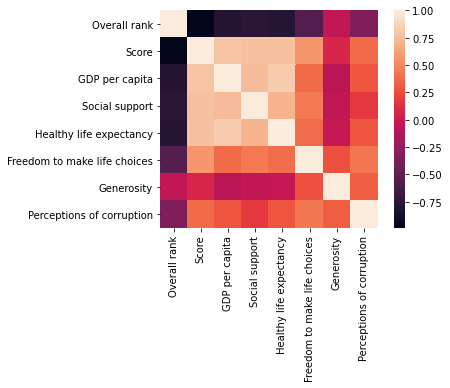

In [4]:
corrmat = df.corr()
f, ax = plt.subplots()
sns.heatmap(corrmat, square=True)

**Plotting pairwise relationships in the dataset.**

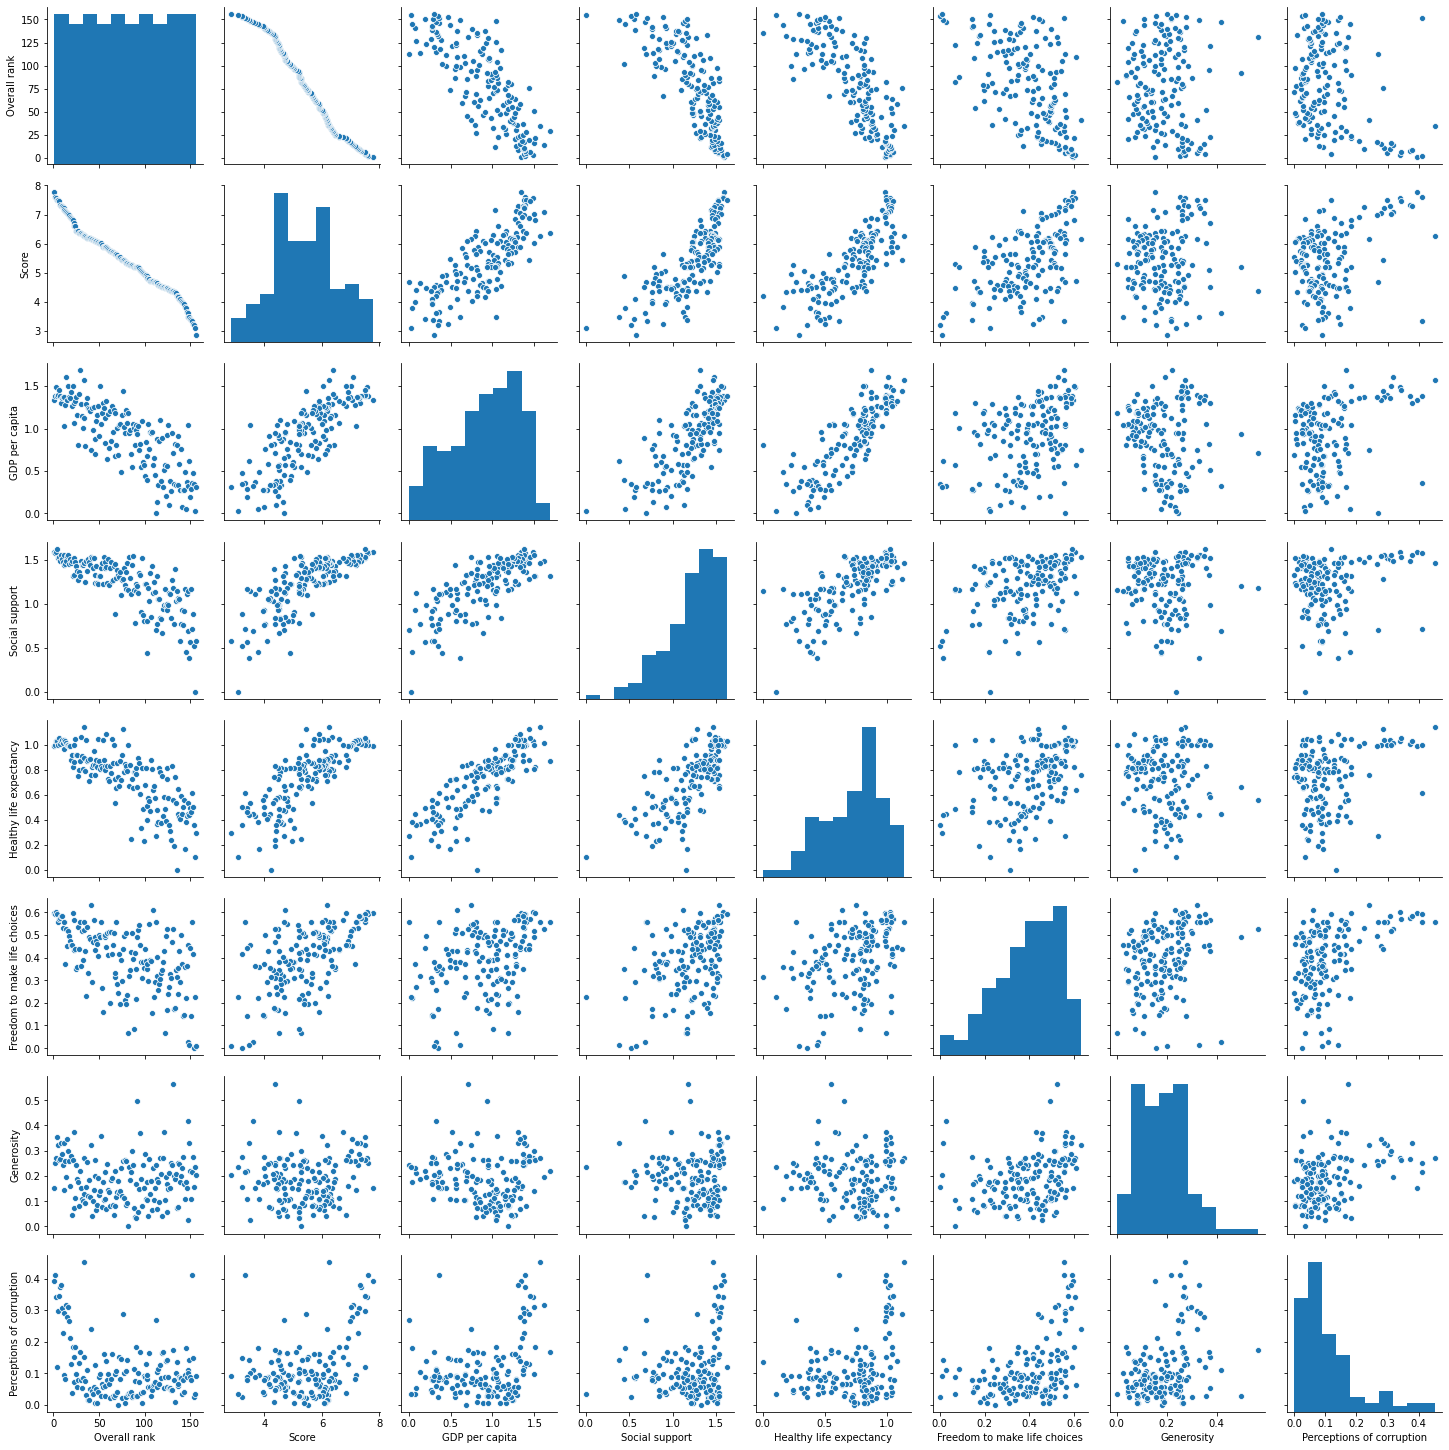

In [5]:
sns.pairplot(df)

**Top 10 countries for each attribute.**

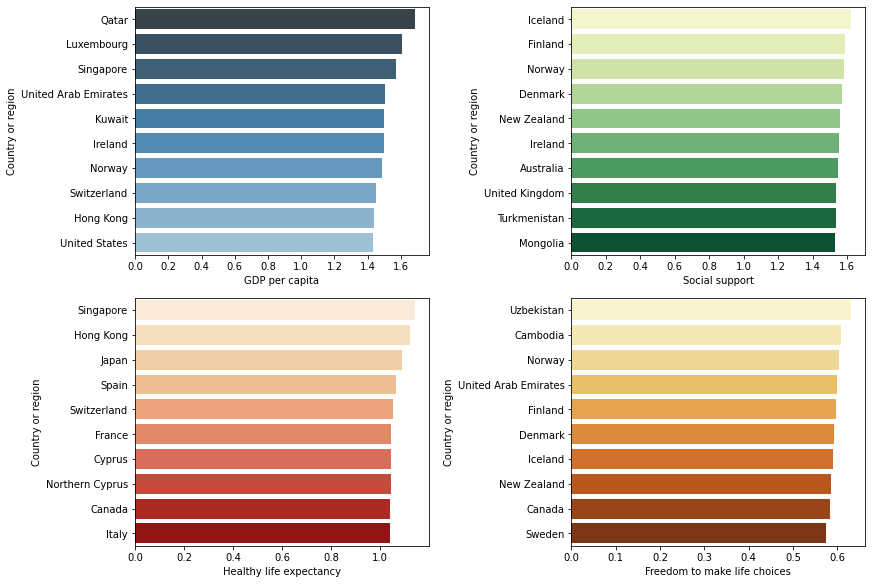

In [6]:

fig, axes = plt.subplots(nrows=2, ncols=2,constrained_layout=True,figsize=(12,8))

sns.barplot(x='GDP per capita',y='Country or region',data=df.nlargest(10,'GDP per capita'),ax=axes[0,0],palette="Blues_d")

sns.barplot(x='Social support' ,y='Country or region',data=df.nlargest(10,'Social support'),ax=axes[0,1],palette="YlGn")

sns.barplot(x='Healthy life expectancy' ,y='Country or region',data=df.nlargest(10,'Healthy life expectancy'),ax=axes[1,0],palette='OrRd')

sns.barplot(x='Freedom to make life choices' ,y='Country or region',data=df.nlargest(10,'Freedom to make life choices'),ax=axes[1,1],palette='YlOrBr')

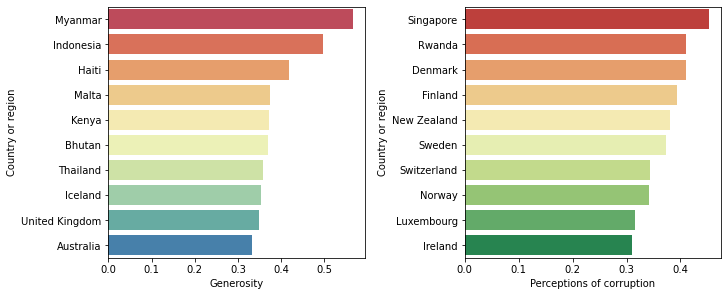

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=2,constrained_layout=True,figsize=(10,4))

sns.barplot(x='Generosity' ,y='Country or region',data=df.nlargest(10,'Generosity'),ax=axes[0],palette='Spectral')
sns.barplot(x='Perceptions of corruption' ,y='Country or region',data=df.nlargest(10,'Perceptions of corruption'),ax=axes[1],palette='RdYlGn')

**Now I want to give a category to each country as High,Mid and Low according to their happiness scores.Thus we have to find out the bound in which these categories shall lie in.**

In [8]:
print('max:',df['Score'].max())
print('min:',df['Score'].min())
add=df['Score'].max()-df['Score'].min()
grp=round(add/3,3)
print('range difference:',(grp))

max: 7.769
min: 2.853
range difference: 1.639


In [9]:
low=df['Score'].min()+grp
mid=low+grp

print('upper bound of Low grp',low)
print('upper bound of Mid grp',mid)
print('upper bound of High grp','max:',df['Score'].max())

upper bound of Low grp 4.492
upper bound of Mid grp 6.131
upper bound of High grp max: 7.769


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


**Finally adding a new column Category to the dataset and distributing the levels High,Low,Mid.**

In [11]:
cat=[]
for i in df.Score:
    if(i>0 and i<low):
        cat.append('Low')
        
        
    elif(i>low and i<mid):
         cat.append('Mid')
    else:
         cat.append('High')

df['Category']=cat  

**Also we will be styling the dataset as a green zone and red zone .If the country belongs to the High category then it is under the green zone and if it is under the Mid or Low category it is goinf to be the red zone**

In [12]:

color = (df.Category == 'High' ).map({True: 'background-color: limegreen',False:'background-color: red'})
df.style.apply(lambda s: color)




,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Category
0,1,Finland,7.769000,1.340000,1.587000,0.986000,0.596000,0.153000,0.393000,High
1,2,Denmark,7.600000,1.383000,1.573000,0.996000,0.592000,0.252000,0.410000,High
2,3,Norway,7.554000,1.488000,1.582000,1.028000,0.603000,0.271000,0.341000,High
3,4,Iceland,7.494000,1.380000,1.624000,1.026000,0.591000,0.354000,0.118000,High
4,5,Netherlands,7.488000,1.396000,1.522000,0.999000,0.557000,0.322000,0.298000,High
5,6,Switzerland,7.480000,1.452000,1.526000,1.052000,0.572000,0.263000,0.343000,High
6,7,Sweden,7.343000,1.387000,1.487000,1.009000,0.574000,0.267000,0.373000,High
7,8,New Zealand,7.307000,1.303000,1.557000,1.026000,0.585000,0.330000,0.380000,High
8,9,Canada,7.278000,1.365000,1.505000,1.039000,0.584000,0.285000,0.308000,High
9,10,Austria,7.246000,1.376000,1.475000,1.016000,0.532000,0.244000,0.226000,High


**Now since I am from India I would like to see my countries position on the list and also checkout some other countries where people from India usually settle  for economic benifits!So lets check them out**

In [13]:
df.loc[df['Country or region']=='India']


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Category
139,140,India,4.015,0.755,0.765,0.588,0.498,0.2,0.085,Low


**Woahhh India is pretty loww on the list, i thought it would make the Mid category but sadly it belongs to the low Category!Now we shall check out Canada,UK and USA**

In [14]:
df.loc[df['Country or region']=='United States']

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Category
18,19,United States,6.892,1.433,1.457,0.874,0.454,0.28,0.128,High


In [15]:
df.loc[df['Country or region']=='United Kingdom']

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Category
14,15,United Kingdom,7.054,1.333,1.538,0.996,0.45,0.348,0.278,High


In [16]:

df.loc[df['Country or region']=='Canada']

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Category
8,9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308,High


**So all of them belong to the HIGH category and apparently Canada is pretty high upand has a great happiness score.No wonder people are flocking to these countries.**

**Lets have a head to head comparison for the above mentioned four countries to understand why they have such a good or a band rank worldwide and get some insight**

In [17]:
d= df[(df['Country or region'].isin(['India','Canada','United Kingdom', 'United States']))]
d

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Category
8,9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308,High
14,15,United Kingdom,7.054,1.333,1.538,0.996,0.450,0.348,0.278,High
18,19,United States,6.892,1.433,1.457,0.874,0.454,0.280,0.128,High
139,140,India,4.015,0.755,0.765,0.588,0.498,0.200,0.085,Low


**Social Support vs GDP per capita vs Healthy life expectancy**

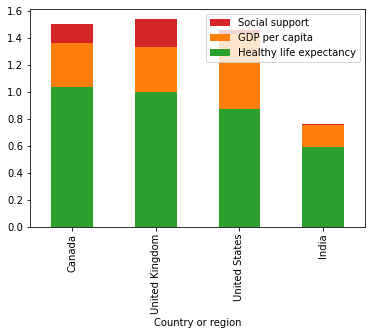

In [18]:

ax = d.plot(y="Social support", x="Country or region", kind="bar",color='C3')
d.plot(y="GDP per capita", x="Country or region", kind="bar", ax=ax, color="C1")
d.plot(y="Healthy life expectancy", x="Country or region", kind="bar", ax=ax, color="C2")

plt.show()


**Freedom to make life choices vs Generosity vs Corruption**

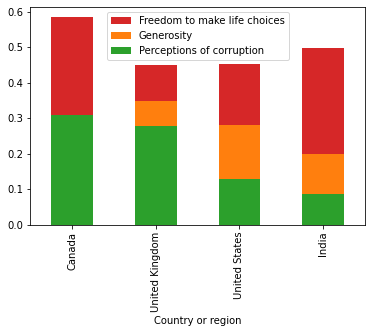

In [19]:
ax = d.plot(y="Freedom to make life choices", x="Country or region", kind="bar",color='C3')
d.plot(y="Generosity", x="Country or region", kind="bar", ax=ax, color="C1",)
d.plot(y="Perceptions of corruption", x="Country or region", kind="bar", ax=ax, color="C2",)

plt.show()

**Geographic Visualization of Happiness Score**

In [20]:
import plotly.graph_objs as go
from plotly.offline import iplot

data = dict(type = 'choropleth', 
           locations = df['Country or region'],
           locationmode = 'country names',
           colorscale='RdYlGn',
           z = df['Score'], 
           text = df['Country or region'],
           colorbar = {'title':'Happiness Score'})

layout = dict(title = 'Geographical Visualization of Happiness Score', 
              geo = dict(showframe = True, projection = {'type': 'azimuthal equal area'}))

choromap3 = go.Figure(data = [data], layout=layout)
iplot(choromap3)

**Checking out previous happiness reports to see changes in attribute distribution**

In [21]:
df15=pd.read_csv('../input/world-happiness/2015.csv')
df16=pd.read_csv('../input/world-happiness/2016.csv')
df17=pd.read_csv('../input/world-happiness/2017.csv')
df18=pd.read_csv('../input/world-happiness/2018.csv')

In [22]:
df15.head(2)

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201


In [23]:
df16.head(2)

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463


In [24]:
df17.head(2)

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707


In [25]:
df18.head(2)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340


**Lets consider Economy(monetary),Social Support(family) and Health as primary concerns for an individual residing in a country i.e overall wellbeing.Lets see how these distributions are altering over the years or are staying stagnant.**

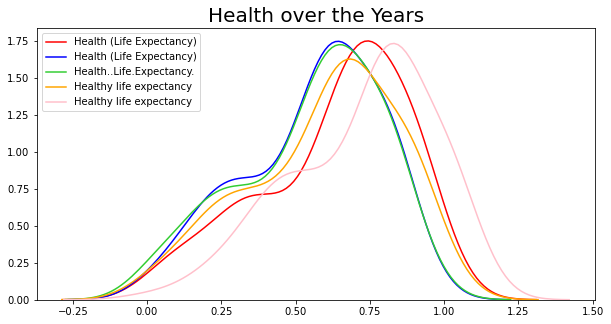

In [26]:
plt.figure(figsize=(10,5))
sns.kdeplot(df15['Health (Life Expectancy)'],color='red')
sns.kdeplot(df16['Health (Life Expectancy)'],color='blue')
sns.kdeplot(df17['Health..Life.Expectancy.'],color='limegreen')
sns.kdeplot(df18['Healthy life expectancy'],color='orange')
sns.kdeplot(df['Healthy life expectancy'],color='pink')
plt.title('Health over the Years',size=20)
plt.show()

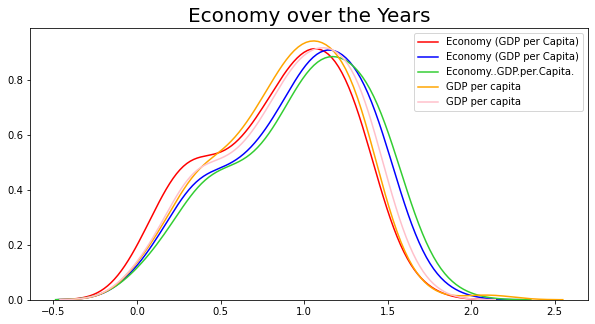

In [27]:
plt.figure(figsize=(10,5))
sns.kdeplot(df15['Economy (GDP per Capita)'],color='red')
sns.kdeplot(df16['Economy (GDP per Capita)'],color='blue')
sns.kdeplot(df17['Economy..GDP.per.Capita.'],color='limegreen')
sns.kdeplot(df18['GDP per capita'],color='orange')
sns.kdeplot(df['GDP per capita'],color='pink')
plt.title('Economy over the Years',size=20)
plt.show()

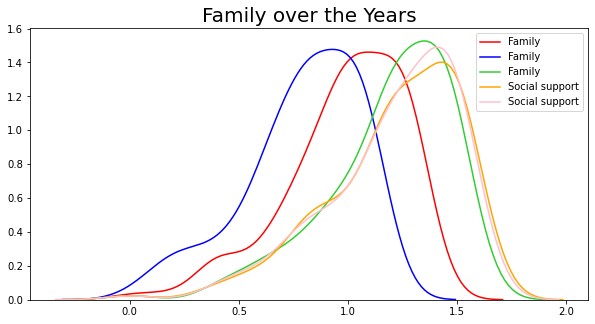

In [28]:
plt.figure(figsize=(10,5))
sns.kdeplot(df15['Family'],color='red')
sns.kdeplot(df16['Family'],color='blue')
sns.kdeplot(df17['Family'],color='limegreen')
sns.kdeplot(df18['Social support'],color='orange')
sns.kdeplot(df['Social support'],color='pink')
plt.title('Family over the Years',size=20)
plt.show()

**Next in line is the relationship between Freedom and Corruption prevalent in the government.**
**Corruption is an enormous obstacle to the realization of all human rights – civil, political, economic, social and cultural, as well as the right to development. Corruption violates the core human rights principles of transparency, accountability, non-discrimination and meaningful participation in every aspect of the life of the community.[src](https://www.u4.no/topics/human-rights/basics)**

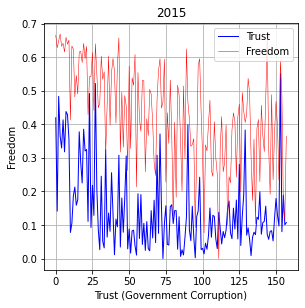

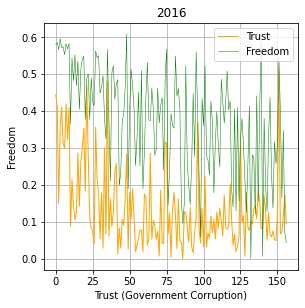

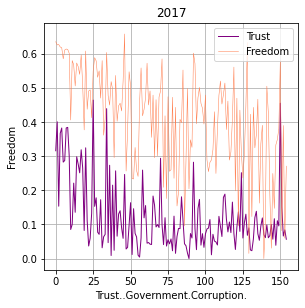

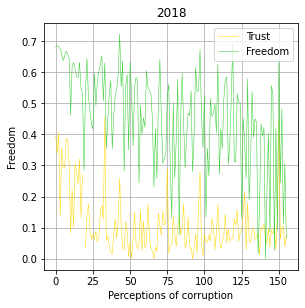

In [29]:
fig = plt.figure(figsize=(10,10))

plt.subplot(2, 2, 1)
df15["Trust (Government Corruption)"].plot(kind='line', color='blue',label='Trust',linewidth=1,grid=True,linestyle="-")
df15["Freedom"].plot(kind="line", color="red", label="Freedom", linewidth=0.5,grid=True,linestyle="-")
plt.xlabel('Trust (Government Corruption)')
plt.ylabel('Freedom')
plt.title('2015')
plt.legend(loc='upper right')
plt.show()

fig = plt.figure(figsize=(10,10))
plt.subplot(2, 2, 2)
df16["Trust (Government Corruption)"].plot(kind='line', color='orange',label='Trust',linewidth=1,grid=True,linestyle="-")
df16["Freedom"].plot(kind="line", color="green", label="Freedom", linewidth=0.5,grid=True,linestyle="-")
plt.xlabel('Trust (Government Corruption)')
plt.ylabel('Freedom')
plt.title('2016')
plt.legend(loc='upper right')
plt.show()

fig = plt.figure(figsize=(10,10))
plt.subplot(2, 2, 3)
df17["Trust..Government.Corruption."].plot(kind='line', color='purple',label='Trust',linewidth=1,grid=True,linestyle="-")
df17["Freedom"].plot(kind="line", color="coral", label="Freedom", linewidth=0.5,grid=True,linestyle="-")
plt.xlabel('Trust..Government.Corruption.')
plt.ylabel('Freedom')
plt.title('2017')
plt.legend(loc='upper right')
plt.show()

fig = plt.figure(figsize=(10,10))
plt.subplot(2, 2, 4)
df18["Perceptions of corruption"].plot(kind='line', color='gold',label='Trust',linewidth=0.5,grid=True,linestyle="-")
df18["Freedom to make life choices"].plot(kind="line", color="limegreen", label="Freedom", linewidth=0.5,grid=True,linestyle="-")
plt.xlabel('Perceptions of corruption')
plt.ylabel('Freedom')
plt.title('2018')
plt.legend(loc='upper right')
plt.show()


**Adding new attribute Year**

In [30]:
df18['Year']='2018'
df['Year']='2019'
df15['Year']='2015'
df16['Year']='2016'
df17['Year']='2017'

**Appending multiple dataframes for extracting more information.Thus we will be selecting some attributes from ecery dataset and also changing their column names and making them similar to ease out the appending part**

In [31]:
df.rename(columns={'Country or region':'Country'},inplace=True)
data1=df.filter(['Country','GDP per capita','Year'],axis=1)

df15.rename(columns={'Economy (GDP per Capita)':'GDP per capita'},inplace=True)
data2=df15.filter(['Country','GDP per capita',"Year"],axis=1)

df16.rename(columns={'Economy (GDP per Capita)':'GDP per capita'},inplace=True)
data3=df16.filter(['Country','GDP per capita',"Year"],axis=1)

df17.rename(columns={'Economy..GDP.per.Capita.':'GDP per capita'},inplace=True)
data4=df17.filter(['Country','GDP per capita','Year'],axis=1)

df18.rename(columns={'Country or region':'Country'},inplace=True)
data5=df18.filter(['Country','GDP per capita',"Year"],axis=1)

data2=data2.append([data3,data4,data5,data1])

We have a new dataframe with info of 2015-2019 GDP per capita of every country

**Checking out GDP per capita of INDIA,USA,UK,CANADA,FINLAND from 2015-19**

Text(0.5, 1.0, 'GDP per capita 2015-2019')

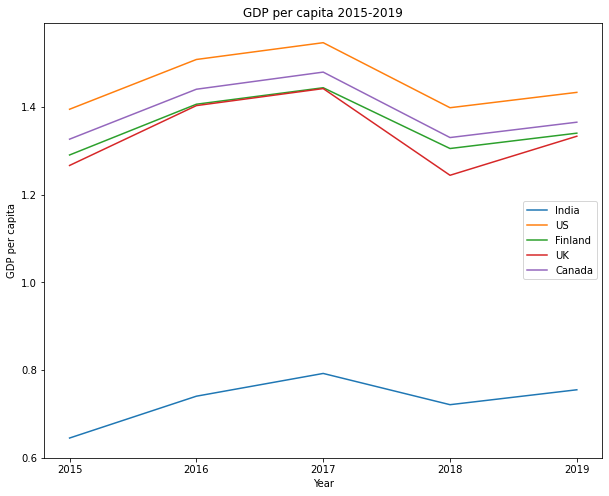

In [32]:
plt.figure(figsize=(10,8))
df = data2[data2['Country']=='India']
sns.lineplot(x="Year", y="GDP per capita",data=df,label='India')

df = data2[data2['Country']=='United States']
sns.lineplot(x="Year", y="GDP per capita",data=df,label='US')

df = data2[data2['Country']=='Finland']
sns.lineplot(x="Year", y="GDP per capita",data=df,label='Finland')

df = data2[data2['Country']=='United Kingdom']
sns.lineplot(x="Year", y="GDP per capita",data=df,label="UK")

df = data2[data2['Country']=='Canada']
sns.lineplot(x="Year", y="GDP per capita",data=df,label='Canada')

plt.title("GDP per capita 2015-2019")

**From this graph we can observe the following:-**
* Indias economy was at its peak in 2017, dropped in 2018 and was recovering in 2019
* US has the highest economy
* UKs economy dipped quite a bit in 2018
* Finland and UK had similar economy ranges in the year 2016-2017

**Heatmap for first 10 countries(alphabetical order) and their GDP per capita over the years**

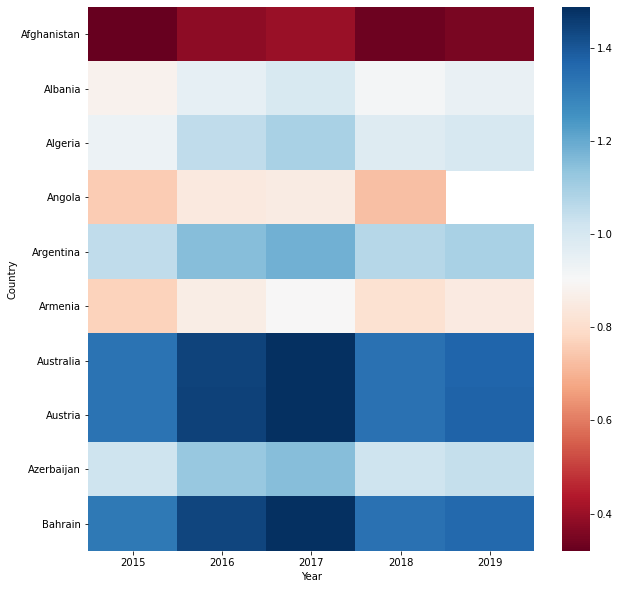

In [33]:
plt.figure(figsize=(10, 10))
h=pd.pivot_table(data2,values='GDP per capita',
index=['Country'],
columns='Year')
h=h.head(10)
sns.heatmap(h,cmap="RdBu")

# **HIERARCHICAL CLUSTERING(with 2019)**

**Hierarchical clustering, also known as hierarchical cluster analysis, is an algorithm that groups similar objects into groups called clusters. The endpoint is a set of clusters, where each cluster is distinct from each other cluster, and the objects within each cluster are broadly similar to each other.**[src](https://www.analyticsvidhya.com/blog/2019/05/beginners-guide-hierarchical-clustering/)

There are multiple Attributes or practices in this case on which the happiness score depends on – GDP,Family,Health,Corruption etc. Our aim is to make clusters from this data that can segment similar countries together. We will use Hierarchical Clustering for this problem.

In [34]:
original=original.drop(['Country or region','Overall rank'],axis=1)

**But before applying Hierarchical Clustering, we have to normalize the data so that the scale of each variable is the same. Why is this important? Well, if the scale of the variables is not the same, the model might become biased towards the variables with a higher magnitude**

In [35]:

from sklearn.preprocessing import normalize
data_scaled = normalize(original)
data_scaled = pd.DataFrame(data_scaled, columns=original.columns)
datasc=data_scaled.copy()
data_scaled.head()

,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,0.955020,0.164722,0.195085,0.121206,0.073264,0.018808,0.048310
1,0.952077,0.173253,0.197055,0.124772,0.074162,0.031569,0.051362
2,0.948783,0.186893,0.198699,0.129117,0.075737,0.034038,0.042830
3,0.949879,0.174918,0.205845,0.130048,0.074910,0.044870,0.014957
4,0.952236,0.177527,0.193550,0.127041,0.070833,0.040948,0.037896


**Let’s draw the dendrogram(A dendrogram is a tree-like diagram that records the sequences of merges or splits)to help us decide the number of clusters for the problem**

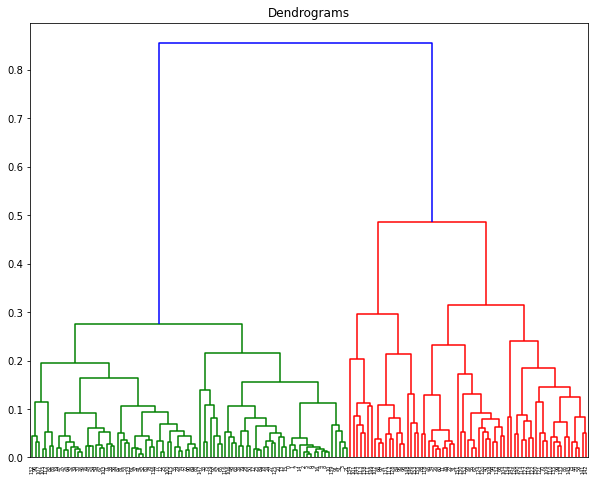

In [36]:

import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10, 8))  
plt.title("Dendrograms")  
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))

The x-axis contains the samples and y-axis represents the distance between these samples.

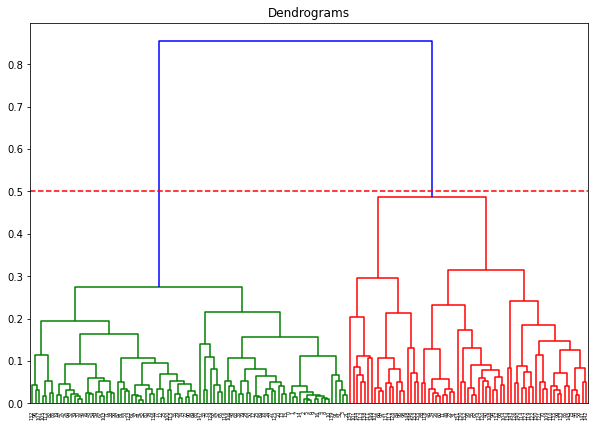

In [37]:
plt.figure(figsize=(10, 7))  
plt.title("Dendrograms")  
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))
plt.axhline(y=0.5, color='r', linestyle='--')

**We have two clusters as this line cuts the dendrogram at two points. Let’s now apply hierarchical clustering for 2 clusters**

In [38]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=2, affinity='euclidean', linkage='ward')  
cluster.fit_predict(data_scaled)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0])

* **0-belongs to cluster number 1**
* **1-belongs to cluster number 2**

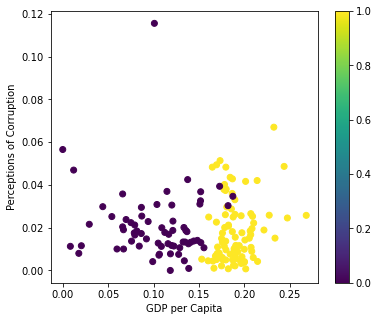

In [39]:
plt.figure(figsize=(6, 5))  
plt.scatter(data_scaled['GDP per capita'], data_scaled['Perceptions of corruption'], c=cluster.labels_) 
plt.xlabel('GDP per Capita')
plt.ylabel('Perceptions of Corruption')
plt.colorbar()

**So here we can clearly see two well defined clusters**

# **K MEANS CLUSTERING**

**k-means is one of the simplest unsupervised learning algorithms that solve the well known clustering problem. The procedure follows a simple and easy way to classify a given data set through a certain number of clusters (assume k clusters) fixed apriori. The main idea is to define k centers, one for each cluster.**

Let’s pick these two variables and visualize the data points

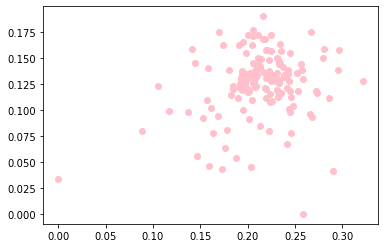

In [40]:
X = datasc[["Social support","Healthy life expectancy"]]
plt.scatter(X["Social support"],X["Healthy life expectancy"],c='pink')
plt.show()

**Now on performing K MEANS CLUSTERING with 3 clusters**

[[0.25122217 0.11686624]
 [0.1455177  0.07640553]
 [0.2054251  0.13849264]]


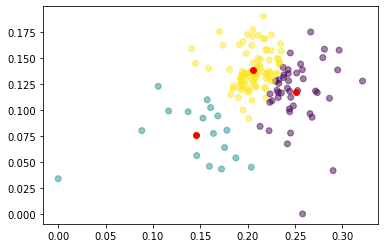

In [41]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3).fit(X)
centroids = kmeans.cluster_centers_
print(centroids)

plt.scatter(X['Social support'], X['Healthy life expectancy'], c= kmeans.labels_.astype(float), alpha=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red')
plt.show()

**So here we can clearly see three well defined clusters with their centroids**